In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/AI/MushroomDataset/secondary_data.csv', sep=';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [6]:
df.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


In [7]:
df.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


In [8]:
df.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color',
       'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color',
       'habitat', 'season'],
      dtype='object')

In [10]:
print('Съедобные грибы (e) составляют', round(df['class'].value_counts()['e']/len(df) * 100,2), '% данных')
print('Ядовитые грибы (p) составляют', round(df['class'].value_counts()['p']/len(df) * 100,2), '% данных')

Съедобные грибы (e) составляют 44.51 % данных
Ядовитые грибы (p) составляют 55.49 % данных


In [14]:
print(df['class'].value_counts())

class
p    33888
e    27181
Name: count, dtype: int64


Text(0.5, 1.0, 'Распределение классов\n (e: Съедобные || p: Ядовитые)')

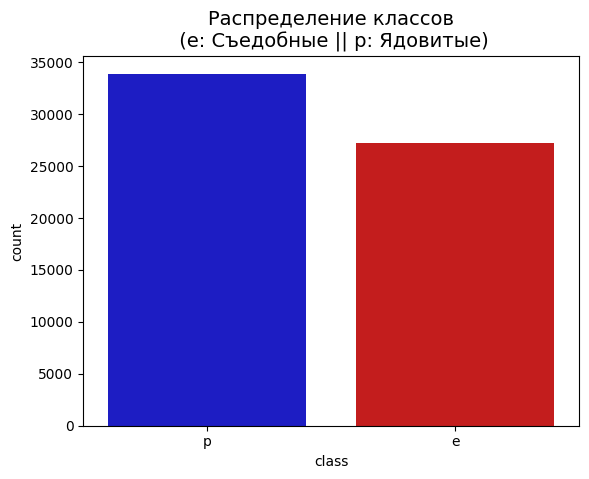

In [15]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='class', data=df, palette=colors)
plt.title('Распределение классов\n (e: Съедобные || p: Ядовитые)', fontsize=14)

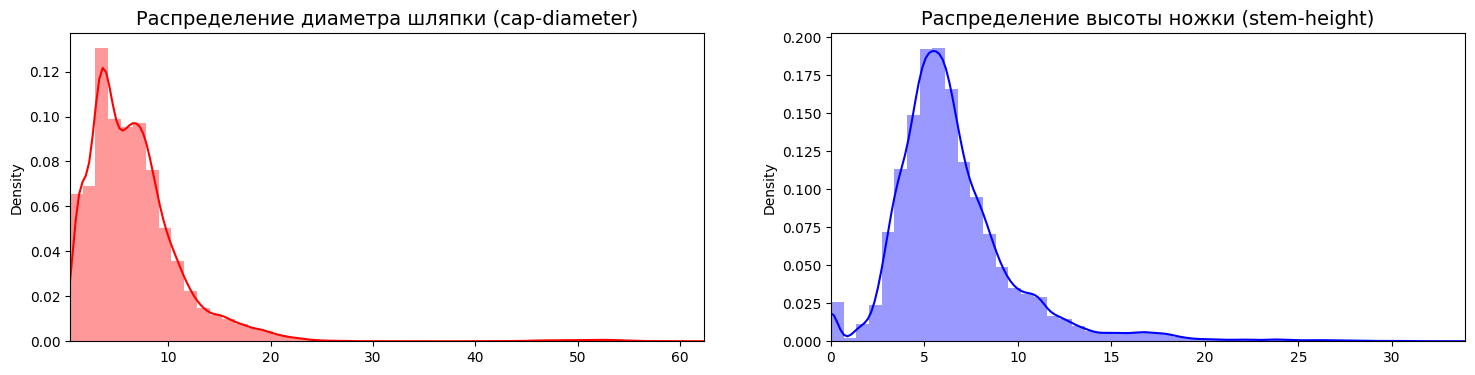

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

cap_diameter_val = df['cap-diameter'].values
stem_height_val = df['stem-height'].values

sns.distplot(cap_diameter_val, ax=ax[0], color='r')
ax[0].set_title('Распределение диаметра шляпки (cap-diameter)', fontsize=14)
ax[0].set_xlim([min(cap_diameter_val), max(cap_diameter_val)])

sns.distplot(stem_height_val, ax=ax[1], color='b')
ax[1].set_title('Распределение высоты ножки (stem-height)', fontsize=14)
ax[1].set_xlim([min(stem_height_val), max(stem_height_val)])

plt.show()

Масштабирование

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
df_encoded = df.copy()

Кодируем целевую переменную

In [23]:
le_class = LabelEncoder()
df_encoded['class'] = le_class.fit_transform(df_encoded['class'])  # e->0, p->1

Кодируем категориальные признаки

In [24]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('class')
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [28]:
rob_scaler = RobustScaler()

X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2, random_state = 42)

numeric_cols = ['cap-diameter', 'stem-height', 'stem-width']

for col in numeric_cols:
    original_Xtrain[f'scaled_{col}'] = rob_scaler.fit_transform(original_Xtrain[col].values.reshape(-1, 1))
    original_Xtest[f'scaled_{col}'] = rob_scaler.transform(original_Xtest[col].values.reshape(-1, 1))

original_Xtrain.drop(numeric_cols, axis=1, inplace=True)
original_Xtest.drop(numeric_cols, axis=1, inplace=True)

original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label / len(original_ytrain))
print("Тестовый набор:", test_counts_label / len(original_ytest))

Распределение классов: 

Обучающий набор: [0.44636168 0.55363832]
Тестовый набор: [0.4399869 0.5600131]


Метод Random Under-Sampling

In [34]:
df_shuffled = df.sample(frac=1)

poisonous = df_shuffled[df_shuffled['class'] == 'p']
edible = df_shuffled[df_shuffled['class'] == 'e']

min_count = min(len(poisonous), len(edible))
edible_balanced = edible[:min_count]
poisonous_balanced = poisonous[:min_count]

normal_distributed_df = pd.concat([edible_balanced, poisonous_balanced])

# Перемешивание строк датасета
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
51011,p,7.67,p,NaN,n,f,p,NaN,p,9.51,...,c,NaN,n,NaN,NaN,f,f,p,d,u
9222,e,3.56,b,g,n,f,x,d,w,3.76,...,NaN,NaN,y,NaN,NaN,f,f,NaN,g,a
14060,p,7.28,f,w,e,f,x,NaN,w,18.48,...,r,g,n,NaN,NaN,f,f,NaN,d,a
53108,e,6.81,x,h,n,f,p,d,y,7.18,...,NaN,s,n,NaN,NaN,f,f,NaN,d,u
24718,e,8.79,x,s,u,f,a,c,w,4.27,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u


Сохраняем новый датасет

In [36]:
new_df.to_csv("/content/drive/MyDrive/AI/MushroomDataset/mushroom_new_df.csv")

In [37]:
new_df.shape

(54362, 21)

Распределение классов в подвыборке
class
p    0.5
e    0.5
Name: count, dtype: float64


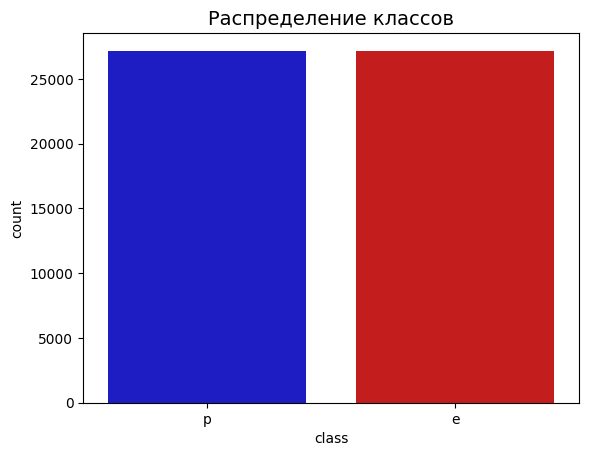

In [38]:
print('Распределение классов в подвыборке')
print(new_df['class'].value_counts()/len(new_df))

# проверяем снова распределение целевой переменной
sns.countplot(x='class', data = new_df, palette = colors)
plt.title('Распределение классов', fontsize=14)
plt.show()

Матрица корреляций

кодируем целевую переменную

In [49]:
le_class = LabelEncoder()
new_df['class'] = le_class.fit_transform(new_df['class'])

кодируем все категориальные признаки

In [50]:
categorical_cols = new_df.select_dtypes(include=['object']).columns.tolist()
if 'class' in categorical_cols:
    categorical_cols.remove('class')

for col in categorical_cols:
    le = LabelEncoder()
    new_df[col] = le.fit_transform(new_df[col])

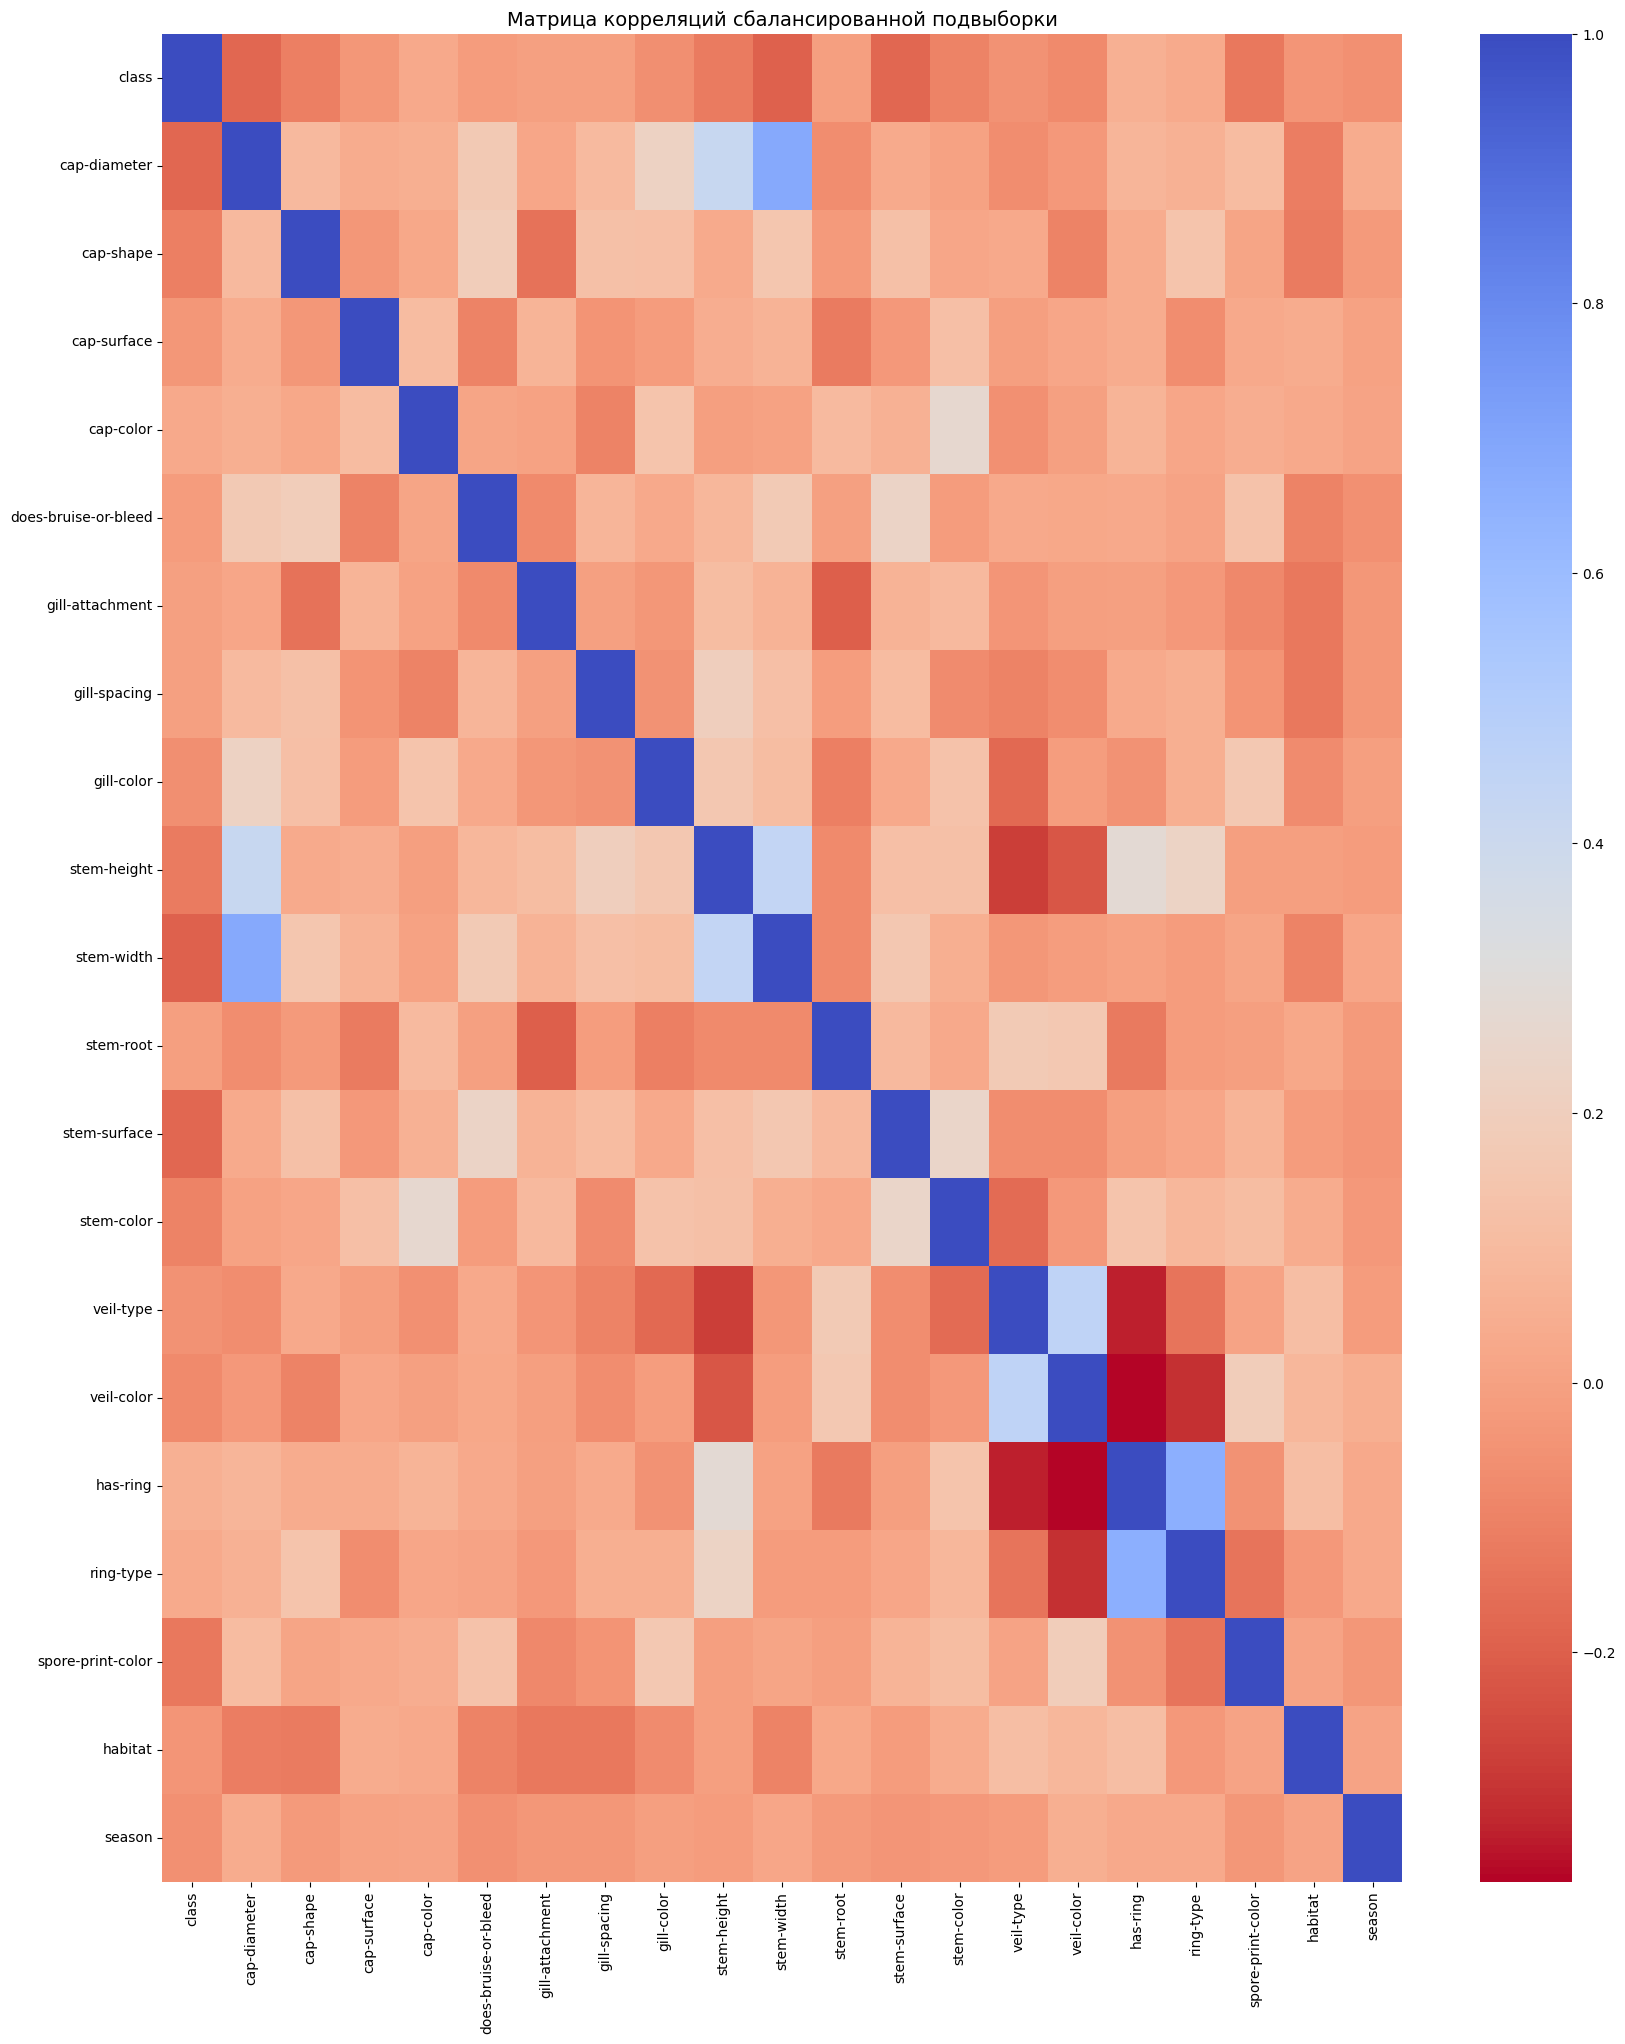

In [51]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

# Построим матрицу корреляций

sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap = 'coolwarm_r', annot_kws ={'size':20}, ax=ax)
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()

строим Boxplot

выбираем самые коррелирующие признаки и строим

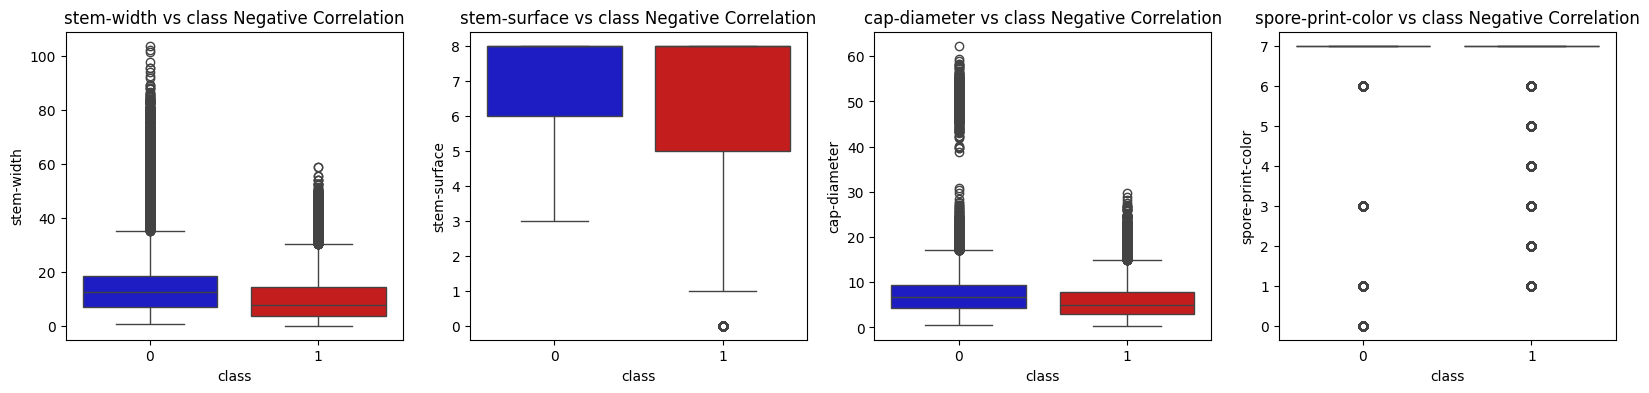

In [56]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# stem-width
sns.boxplot(x='class', y='stem-width', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('stem-width vs class Negative Correlation')

# stem-surface
sns.boxplot(x='class', y='stem-surface', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('stem-surface vs class Negative Correlation')


# cap-diameter
sns.boxplot(x='class', y='cap-diameter', data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('cap-diameter vs class Negative Correlation')


# spore-print-color
sns.boxplot(x='class', y='spore-print-color', data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('spore-print-color vs class Negative Correlation')

plt.show()

Обработка выбросов

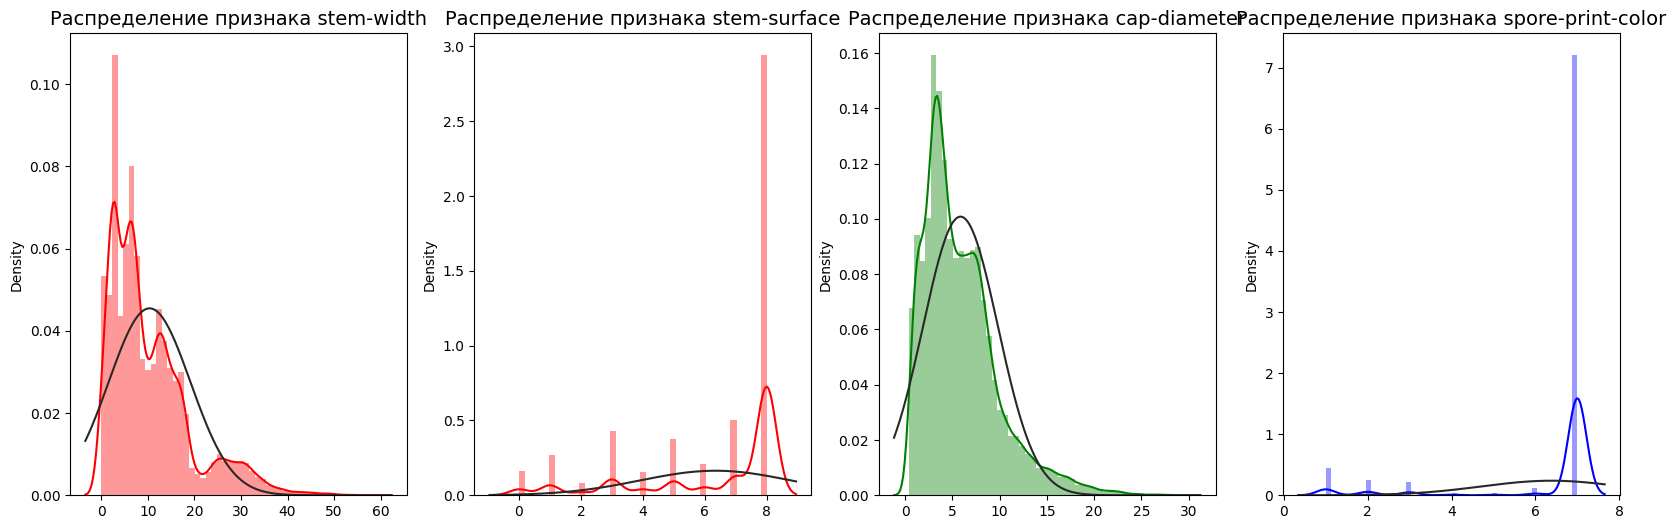

In [59]:
# Строим распределения для stem-width, stem-surface, cap-diameter, spore-print-color

from scipy.stats import norm

f, (ax1, ax2, ax3, ax4) = plt.subplots(1,4, figsize=(20, 6))

####
stem_width_fraud_dist = new_df['stem-width'].loc[new_df['class'] == 1].values

sns.distplot(stem_width_fraud_dist, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение признака stem-width', fontsize=14)

####
stem_surface_fraud_dist = new_df['stem-surface'].loc[new_df['class'] == 1].values

sns.distplot(stem_surface_fraud_dist, ax=ax2, fit=norm, color='r')
ax2.set_title('Распределение признака stem-surface', fontsize=14)

####
cap_diameter_fraud_dist = new_df['cap-diameter'].loc[new_df['class'] == 1].values

sns.distplot(cap_diameter_fraud_dist, ax=ax3, fit=norm, color='g')
ax3.set_title('Распределение признака cap-diameter', fontsize=14)

####
spore_print_color_fraud_dist = new_df['spore-print-color'].loc[new_df['class'] == 1].values

sns.distplot(spore_print_color_fraud_dist, ax=ax4, fit=norm, color='b')
ax4.set_title('Распределение признака spore-print-color', fontsize=14)

plt.show()

In [66]:
# Удаление выбросов из признака stem-width
stem_width_fraud = new_df['stem-width'].loc[new_df['class'] == 1].values
q25, q75 = np.percentile(stem_width_fraud, 25), np.percentile(stem_width_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
stem_width_iqr = q75 - q25
print('iqr: {}'.format(stem_width_iqr))

stem_width_cut_off = stem_width_iqr * 1.5
stem_width_lower, stem_width_upper = q25 - stem_width_cut_off, q75 + stem_width_cut_off
print('Порог: {}'.format(stem_width_cut_off))
print('stem_width нижняя граница: {}'.format(stem_width_lower))
print('stem_width верхняя граница: {}'.format(stem_width_upper))

outliers = [x for x in stem_width_fraud if x < stem_width_lower or x > stem_width_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers  = new_df.drop(new_df[(new_df['stem-width'] > stem_width_upper) | (new_df['stem-width'] < stem_width_lower)].index)
print('----' * 44)

Квартиль 25: 3.57 | Квартиль 75: 14.33
iqr: 10.76
Порог: 16.14
stem_width нижняя граница: -12.57
stem_width верхняя граница: 30.47
Количество выбросов: 1198
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [64]:
####
# Удаление выбросов из признака stem-surface
stem_surface_fraud = new_df['stem-surface'].loc[new_df['class'] == 1].values
q25, q75 = np.percentile(stem_surface_fraud, 25), np.percentile(stem_surface_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
stem_surface_iqr = q75 - q25
print('iqr: {}'.format(stem_surface_iqr))

stem_surface_cut_off = stem_surface_iqr * 1.5
stem_surface_lower, stem_surface_upper = q25 - stem_surface_cut_off, q75 + stem_surface_cut_off
print('Порог: {}'.format(stem_surface_cut_off))
print('stem-surface нижняя граница: {}'.format(stem_surface_lower))
print('stem-surface верхняя граница: {}'.format(stem_surface_upper))

outliers = [x for x in stem_surface_fraud if x < stem_surface_lower or x > stem_surface_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers  = new_df.drop(new_df[(new_df['stem-surface'] > stem_surface_upper) | (new_df['stem-surface'] < stem_surface_lower)].index)
print('----' * 44)

Квартиль 25: 5.0 | Квартиль 75: 8.0
iqr: 3.0
Порог: 4.5
stem-surface нижняя граница: 0.5
stem-surface верхняя граница: 12.5
Количество выбросов: 851
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [65]:
####
# Удаление выбросов из признака cap-diameter
cap_diameter_fraud = new_df['cap-diameter'].loc[new_df['class'] == 1].values
q25, q75 = np.percentile(cap_diameter_fraud, 25), np.percentile(cap_diameter_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
cap_diameter_iqr = q75 - q25
print('iqr: {}'.format(cap_diameter_iqr))

cap_diameter_cut_off = cap_diameter_iqr * 1.5
cap_diameter_lower, cap_diameter_upper = q25 - cap_diameter_cut_off, q75 + cap_diameter_cut_off
print('Порог: {}'.format(cap_diameter_cut_off))
print('cap-diameter нижняя граница: {}'.format(cap_diameter_lower))
print('cap-diameter верхняя граница: {}'.format(cap_diameter_upper))
outliers = [x for x in cap_diameter_fraud if x < cap_diameter_lower or x > cap_diameter_upper]
print('Количество выбросов: {}'.format(len(outliers)))
new_df_without_outliers  = new_df_without_outliers.drop(new_df_without_outliers[(new_df_without_outliers['cap-diameter'] > cap_diameter_upper) | (new_df_without_outliers['cap-diameter'] < cap_diameter_lower)].index)
print('----' * 44)

Квартиль 25: 3.04 | Квартиль 75: 7.83
iqr: 4.79
Порог: 7.1850000000000005
cap-diameter нижняя граница: -4.1450000000000005
cap-diameter верхняя граница: 15.015
Количество выбросов: 991
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [67]:
####
# Удаление выбросов из признака spore-print-color
spore_print_color_fraud = new_df['spore-print-color'].loc[new_df['class'] == 1].values
q25, q75 = np.percentile(spore_print_color_fraud, 25), np.percentile(spore_print_color_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
spore_print_color_iqr = q75 - q25
print('iqr: {}'.format(spore_print_color_iqr))

spore_print_color_cut_off = spore_print_color_iqr * 1.5
spore_print_color_lower, spore_print_color_upper = q25 - spore_print_color_cut_off, q75 + spore_print_color_cut_off
print('Порог: {}'.format(spore_print_color_cut_off))
print('spore-print-color нижняя граница: {}'.format(spore_print_color_lower))
print('spore-print-color верхняя граница: {}'.format(spore_print_color_upper))
outliers = [x for x in spore_print_color_fraud if x < spore_print_color_lower or x > spore_print_color_upper]
print('Количество выбросов: {}'.format(len(outliers)))
new_df_without_outliers  = new_df_without_outliers.drop(new_df_without_outliers[(new_df_without_outliers['spore-print-color'] > spore_print_color_upper) | (new_df_without_outliers['spore-print-color'] < spore_print_color_lower)].index)

Квартиль 25: 7.0 | Квартиль 75: 7.0
iqr: 0.0
Порог: 0.0
spore-print-color нижняя граница: 7.0
spore-print-color верхняя граница: 7.0
Количество выбросов: 3688


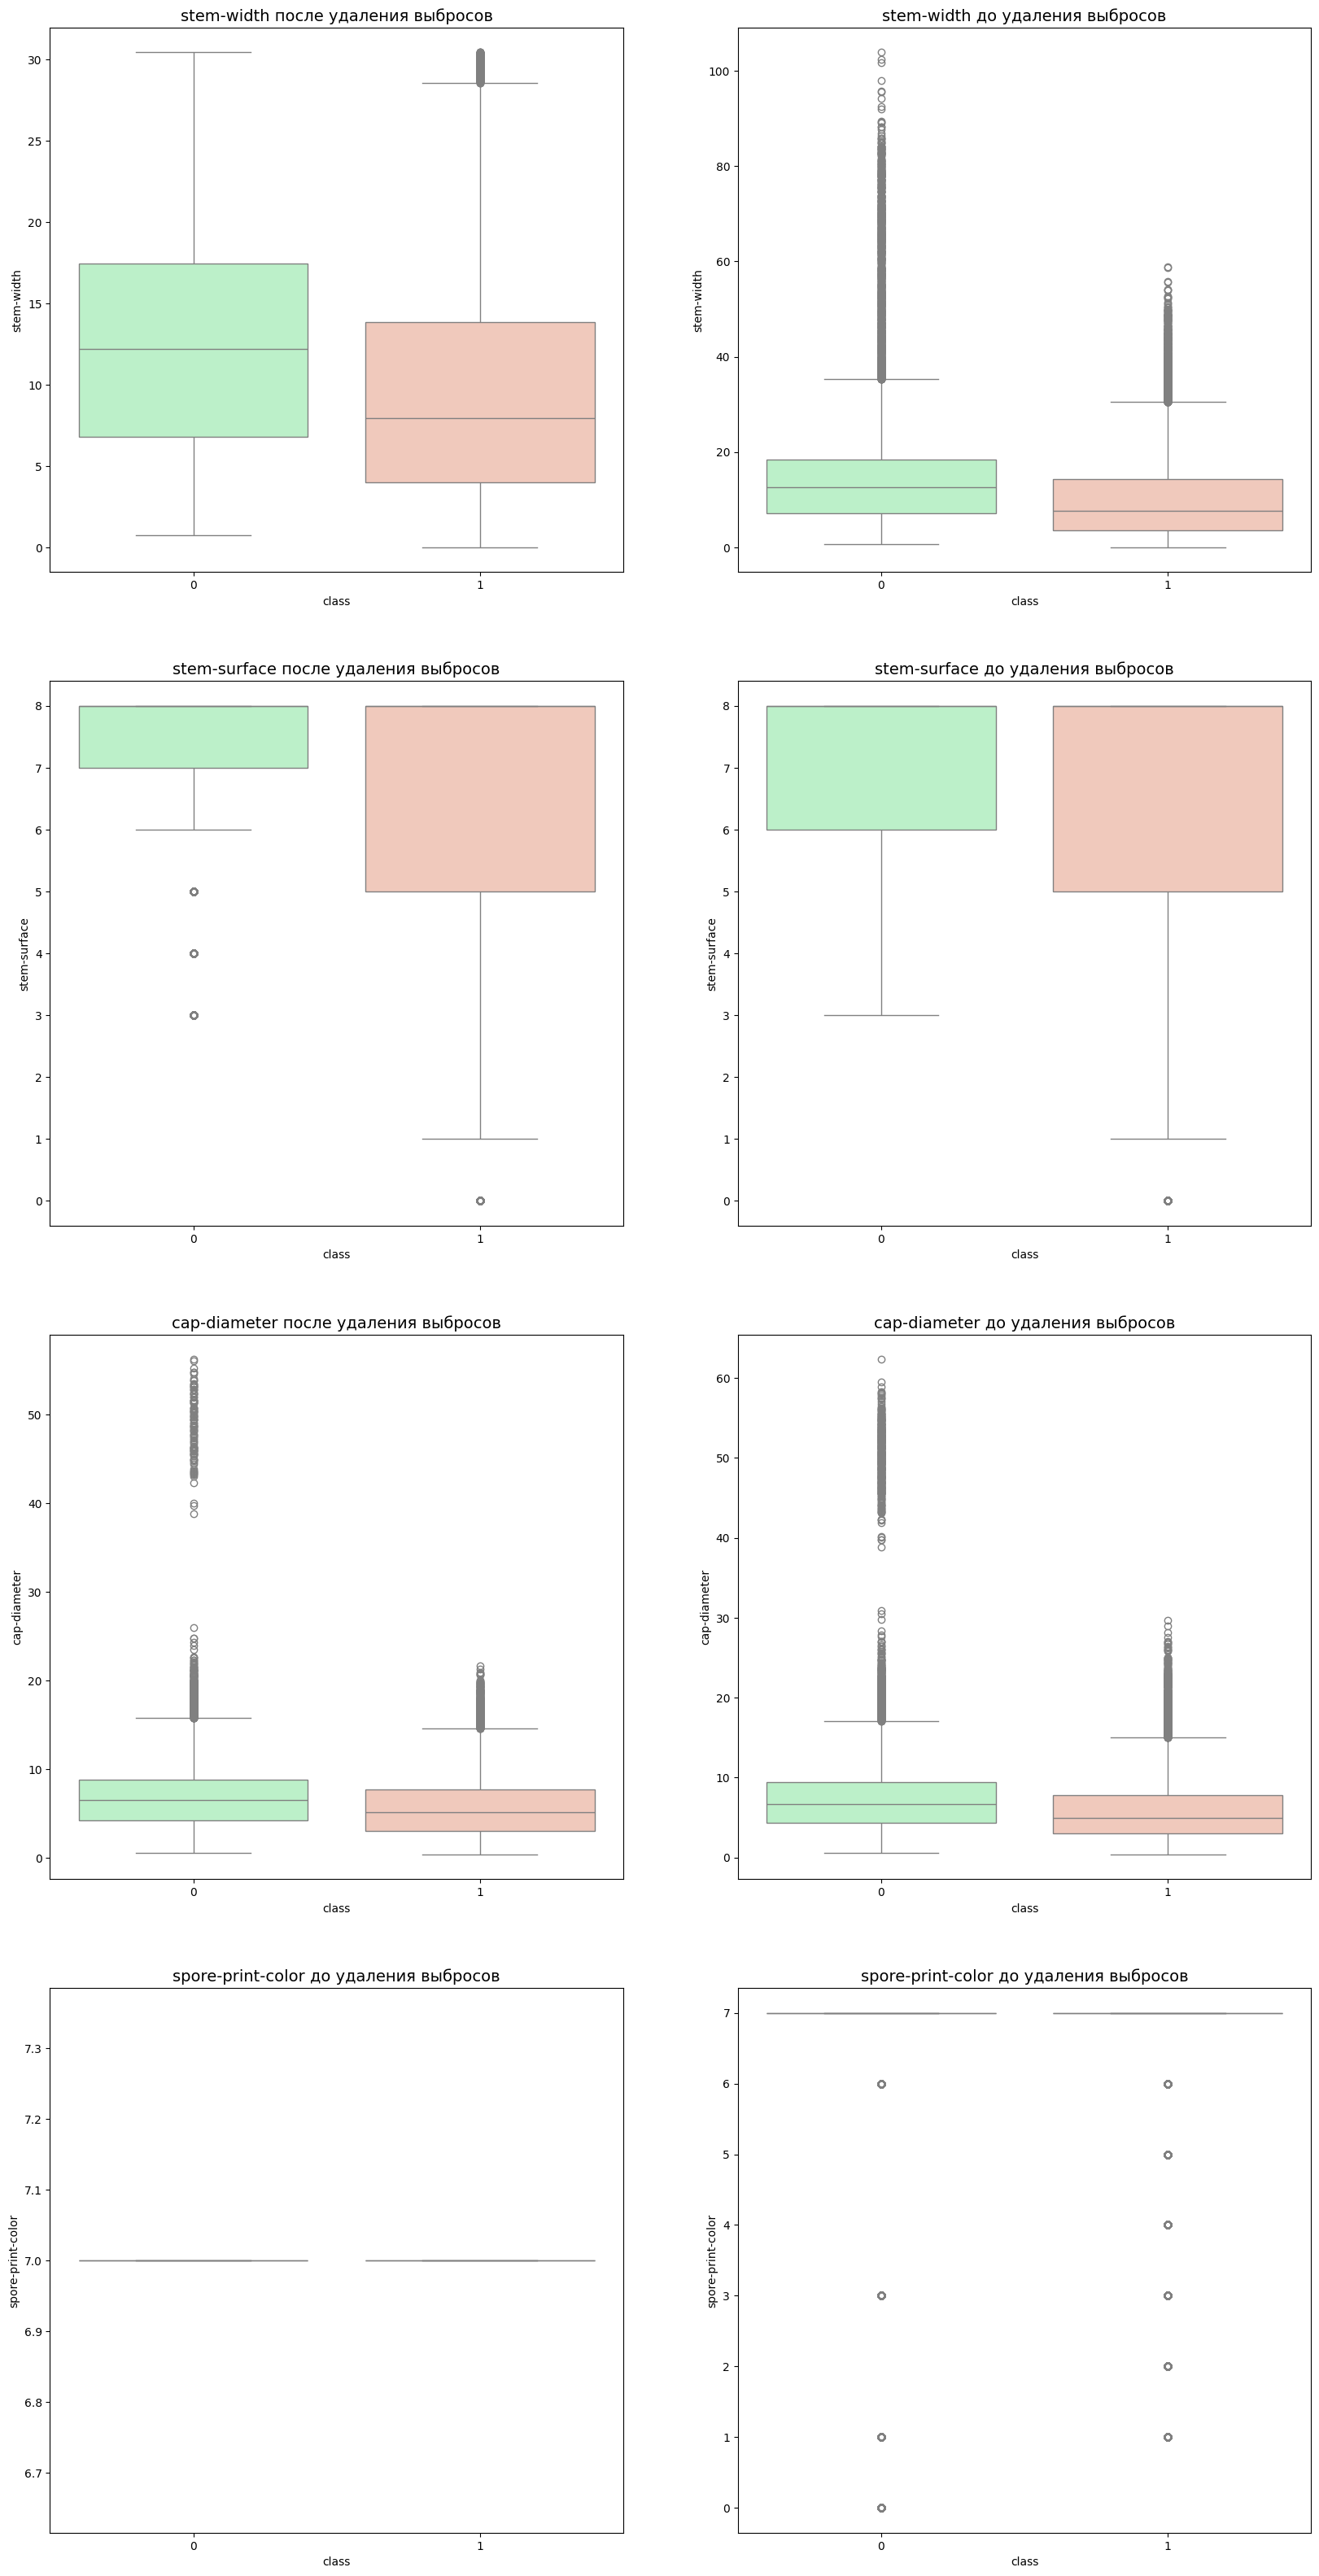

In [76]:
f, ax = plt.subplots(4, 2, figsize=(20,40))

colors = ['#B3F9C5', '#f9c5b3']

# Boxplot для признака stem-width
sns.boxplot(x="class", y="stem-width", data=new_df_without_outliers,ax=ax[0,0], palette=colors)
ax[0,0].set_title("stem-width после удаления выбросов", fontsize=14)
# Boxplot для признака stem-width
sns.boxplot(x="class", y="stem-width", data=new_df,ax=ax[0,1], palette=colors)
ax[0,1].set_title("stem-width до удаления выбросов", fontsize=14)

# Boxplot для признака stem-surface
sns.boxplot(x="class", y="stem-surface", data=new_df_without_outliers,ax=ax[1,0], palette=colors)
ax[1,0].set_title("stem-surface после удаления выбросов", fontsize=14)
# Boxplot для признака stem-surface
sns.boxplot(x="class", y="stem-surface", data=new_df,ax=ax[1,1], palette=colors)
ax[1,1].set_title("stem-surface до удаления выбросов", fontsize=14)

# Boxplot для признака cap-diameter
sns.boxplot(x="class", y="cap-diameter", data=new_df_without_outliers, ax=ax[2,0], palette=colors)
ax[2,0].set_title("cap-diameter после удаления выбросов", fontsize=14)
# Boxplot для признака cap-diameter
sns.boxplot(x="class", y="cap-diameter", data=new_df, ax=ax[2,1], palette=colors)
ax[2,1].set_title("cap-diameter до удаления выбросов", fontsize=14)

# Boxplot для признака spore-print-color
sns.boxplot(x="class", y="spore-print-color", data=new_df_without_outliers, ax=ax[3,0], palette=colors)
ax[3,0].set_title("spore-print-color до удаления выбросов", fontsize=14)
# Boxplot для признака spore-print-color
sns.boxplot(x="class", y="spore-print-color", data=new_df, ax=ax[3,1], palette=colors)
ax[3,1].set_title("spore-print-color до удаления выбросов", fontsize=14)

plt.show()

In [77]:
new_df = new_df_without_outliers

In [79]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

X = new_df.drop('class', axis=1)
y = new_df['class']



# T-SNE алгоритм
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
# ВАШ КОД ЗДЕСЬ
t1 = time.time()
print("T-SNE заняло {:.2} сек".format(t1 - t0))

# PCA алгоритм
t0 = time.time()
# ВАШ КОД ЗДЕСЬ
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA заняло {:.2} сек".format(t1 - t0))

# TruncatedSVD алгоритм
t0 = time.time()
# ВАШ КОД ЗДЕСЬ
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD заняло {:.2} сек".format(t1 - t0))

T-SNE заняло 5.6e+02 сек
PCA заняло 0.033 сек
Truncated SVD заняло 0.085 сек


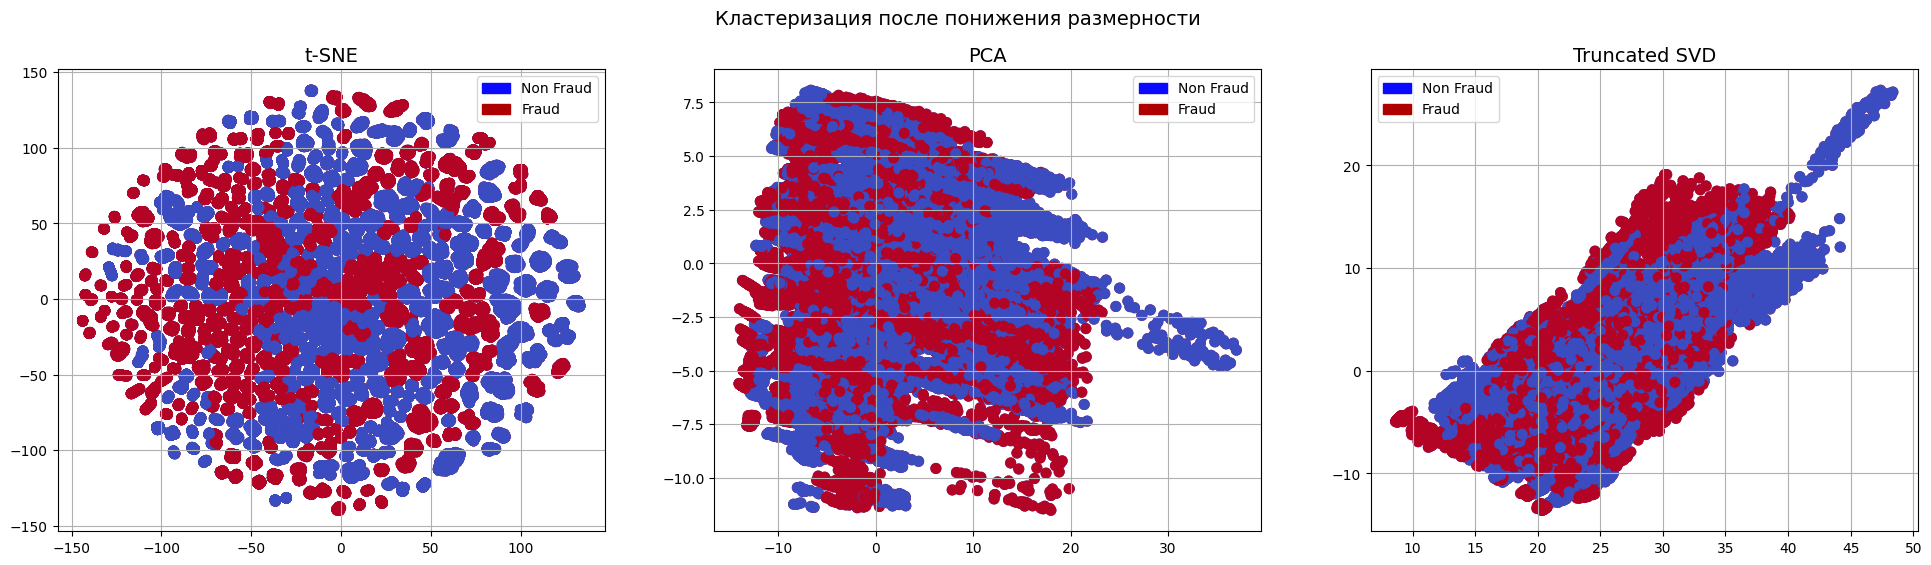

In [80]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Кластеризация после понижения размерности', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='Non Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()